In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from feature_engine.outliers import Winsorizer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.neighbors import KNeighborsRegressor
import pickle

In [2]:
df = pd.read_csv('diamonds.csv')
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [4]:
df.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(146)

In [6]:
print(df.shape)
df = df.drop_duplicates()
df.shape

(53940, 10)


(53794, 10)

In [7]:
df.describe()

,carat,depth,table,price,x,y,z
count,53794.00000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000
mean,0.79778,61.748080,57.458109,3933.065082,5.731214,5.734653,3.538714
std,0.47339,1.429909,2.233679,3988.114460,1.120695,1.141209,0.705037
min,0.20000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.40000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.70000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.04000,62.500000,59.000000,5326.750000,6.540000,6.540000,4.030000
max,5.01000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


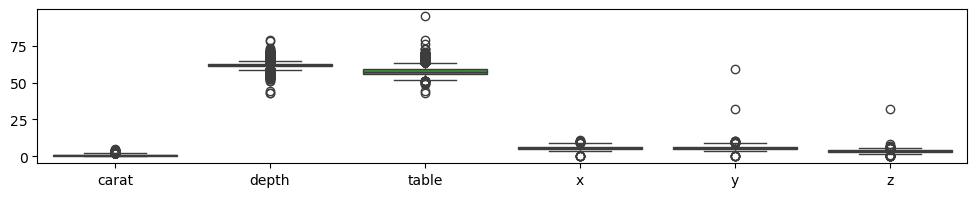

In [8]:
plt.figure(figsize=(12, 2))
sns.boxplot(df.loc[:,'carat':'table'])
sns.boxplot(df.loc[:,'x':])
plt.show()

In [9]:
w = Winsorizer(capping_method ='iqr', tail = 'both', fold = 1.5)
for i in ['carat', 'depth', 'table', 'x', 'y', 'z']:
    df[i]=w.fit_transform(df[[i]])

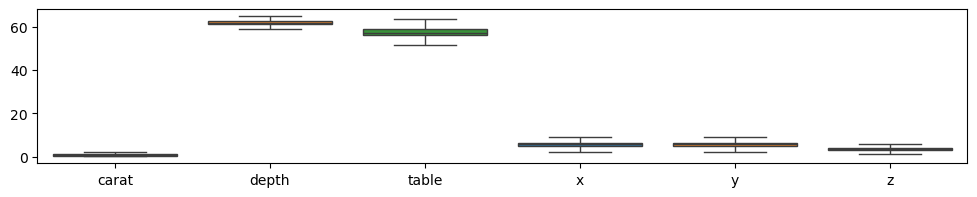

In [10]:
plt.figure(figsize=(12, 2))
sns.boxplot(df.loc[:,'carat':'table'])
sns.boxplot(df.loc[:,'x':])
plt.show()

In [11]:
y = df['price']
x = df.drop(columns = ['price'])
x.shape

(53794, 9)

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
print(x_train.shape)
print(x_test.shape)

(43035, 9)
(10759, 9)


In [13]:
ord_cols=[1,2,3]
std_cols=[0,4,5,6,7,8]

cut_cat = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_cat = ['D', 'E', 'F', 'G', 'H', 'I', 'J']
clarity_cat = ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']

encoder = OrdinalEncoder(
    categories=[cut_cat, color_cat, clarity_cat]
)

ct = ColumnTransformer(transformers = [('t1',StandardScaler(),std_cols),('t2',encoder,ord_cols)])

x_train_trans = ct.fit_transform(x_train)
x_train_trans = pd.DataFrame(x_train_trans)

x_test_trans = ct.transform(x_test)
x_test_trans = pd.DataFrame(x_test_trans)

#### KNN Regressor

In [14]:
knn = KNeighborsRegressor()
knn.fit(x_train_trans, y_train)

KNeighborsRegressor()

In [15]:
y_test_pred = knn.predict(x_test_trans)
y_train_pred = knn.predict(x_train_trans)

In [16]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

print('Train_Accuracy:', round(r2_score(y_train,y_train_pred),5))
print('Test_Accuracy:', round(r2_score(y_test, y_test_pred),5))
print('MAE:', round(mean_absolute_error(y_test, y_test_pred),5))
print('RMSE:', round(root_mean_squared_error(y_test, y_test_pred),5))

Train_Accuracy: 0.97885
Test_Accuracy: 0.96714
MAE: 382.07051
RMSE: 720.49141


In [17]:
with open('diamond_knn_model.pkl','wb') as file:
    pickle.dump(knn,file)
print('Model Saved successfully as diamond_knn_model.pkl')

Model Saved successfully as diamond_knn_model.pkl
